<h1>Содержание<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Подготовка-данных" data-toc-modified-id="Подготовка-данных-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Подготовка данных</a></span></li><li><span><a href="#Обучение-моделей" data-toc-modified-id="Обучение-моделей-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Обучение моделей</a></span></li><li><span><a href="#Выводы" data-toc-modified-id="Выводы-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Выводы</a></span></li></ul></div>

# Обучение модели классификации комментариев

Интернет-магазин «Викишоп» запускает новый сервис. Теперь пользователи могут редактировать и дополнять описания товаров, как в вики-сообществах. То есть клиенты предлагают свои правки и комментируют изменения других. Магазину нужен инструмент, который будет искать токсичные комментарии и отправлять их на модерацию. 

Обучите модель классифицировать комментарии на позитивные и негативные. В вашем распоряжении набор данных с разметкой о токсичности правок.

Постройте модель со значением метрики качества *F1* не меньше 0.75. 

**Ход выполнения проекта**

1. Загрузите и подготовьте данные.
2. Обучите разные модели. 
3. Сделайте выводы.

**Описание данных**

Данные находятся в файле `toxic_comments.csv`. Столбец *text* в нём содержит текст комментария, а *toxic* — целевой признак.

In [1]:
#!pip3 install torch torchvision
!pip install -U scikit-learn -q

In [2]:
import numpy as np
import pandas as pd
import time
import string
import re
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords as nltk_stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import f1_score, confusion_matrix, precision_recall_curve

In [3]:
nltk.download('punkt')  # для токенизации
nltk.download('stopwords')  # список стоп-слов
nltk.download('wordnet')  # англоязычный словарь
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to /home/jovyan/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /home/jovyan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/jovyan/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/jovyan/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [4]:
RANDOM_STATE = 321
TEST_SIZE = 0.25

## Подготовка данных

In [5]:
df_comments = pd.read_csv('https://code.s3.yandex.net/datasets/toxic_comments.csv')
pd.set_option('display.max_colwidth', None)
df_comments.sample(5)

,Unnamed: 0,text,toxic
64272,64339,Yeah where it says seriously...gay thats implying what happen was gay or that the action was gay... You would know that if you where a teen... but your probably an adult loser...,1
91707,91798,Go to the francesca mold discussion board instead! \n\nThats where I've been waiting for my replys!,0
68181,68249,"Infobox_road template standards\nI have added a discussion thread at WT:NJSCR to address standards for NJ road infoboxes and invite your participation. Over the past several weeks, we have made tremendous progress in cleaning up the articles for the State highways in New Jersey, especially with the expansion and addition of infoboxes to most of these articles. However, there seems to be a great deal of confusion as to what should be going in these infoboxes. I am creating this thread and inviting those users who have been active participants in editing these pages to come up with a mutually agreeable answer on the issues listed. I will take on the task of moderating this discussion, but I will add my 2 cents on these topics. We can add more questions if needed, but please, be civil.",0
96140,96232,"""\n\n(1) You have not demonstrated that having multiple articles is necessarily a """"POV fork""""; (2) you have not demonstrated why, if there is such a problem, it can't be solving through editing; (3) you have ignored the clear fact that there is no prospect of any consensus to delete articles. It is very difficult not to conclude that you prefer to keep the page indefinitely protected to seeking a solution. Is there one or more of my points (a) to (c) in my proposal to which you feel you cannot adhere? """,0
30876,30916,"Hi anthony, I am a DCU student.I dont have a sandbox yet, could you please make one for me as I am going to do edits for my subject.\nThank You",0


In [6]:
df_comments['text'].count()

159292

In [7]:
df_comments['toxic'].value_counts()

0    143106
1     16186
Name: toxic, dtype: int64

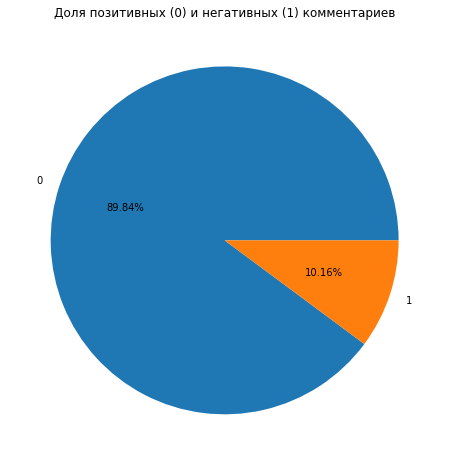

In [8]:
plt.figure(figsize = (12, 8))
plt.pie(df_comments['toxic'].value_counts(), labels=df_comments['toxic'].unique(),  autopct='%1.2f%%')
plt.title('Доля позитивных (0) и негативных (1) комментариев')
plt.show()

In [9]:
df_comments['text'][3]

'"\nMore\nI can\'t make any real suggestions on improvement - I wondered if the section statistics should be later on, or a subsection of ""types of accidents""  -I think the references may need tidying so that they are all in the exact same format ie date format etc. I can do that later on, if no-one else does first - if you have any preferences for formatting style on references or want to do it yourself please let me know.\n\nThere appears to be a backlog on articles for review so I guess there may be a delay until a reviewer turns up. It\'s listed in the relevant form eg Wikipedia:Good_article_nominations#Transport  "'

In [10]:
def text_processing(text):
    text_re = re.sub(r'[^a-zA-Z ]', ' ', text)
    text_splited = text_re.split()
    text = " ".join(text_splited)
    
    text = text.lower()
    
    lemmatizer = WordNetLemmatizer()
    token = nltk.word_tokenize(text)
    tokens_dict = dict(nltk.pos_tag(token))
    
    lemm_tokens = []
    for token, tag in tokens_dict.items():
        if tag.startswith('V'):
            lemm_tokens.append(lemmatizer.lemmatize(token, pos='v')) # verbs
        elif tag.startswith('NN'):
            lemm_tokens.append(lemmatizer.lemmatize(token, pos='n')) # nouns
        elif tag.startswith('J'):
            lemm_tokens.append(lemmatizer.lemmatize(token, pos='a')) # adjectives
        elif tag.startswith('W'):
            lemm_tokens.append(lemmatizer.lemmatize(token, pos='r')) # adverbs
        else:
            lemm_tokens.append(token)
    
    lemm_text = " ".join(lemm_tokens)
    return lemm_text

start = time.time()
df_comments['text'] = df_comments['text'].apply(text_processing)
print(f'Время подготовки текста: {(time.time() - start)/60:.2f} минут')
print('Пример лемматизированного текста:')
df_comments['text'][3]

Время подготовки текста: 8.80 минут
Пример лемматизированного текста:


'more i can t make any real suggestion on improvement wonder if the section statistic should be later or a subsection of type accident think reference may need tidy so that they be all in exact same format ie date etc do no one else do first you have preference for format style want to it yourself please let me know there appear backlog article review guess delay until reviewer turn up s list relevant form eg wikipedia good article nomination transport'

In [12]:
X_train, X_test, y_train, y_test = train_test_split(df_comments['text'], 
                                                    df_comments['toxic'],
                                                    stratify=df_comments['toxic'],
                                                    test_size=TEST_SIZE, 
                                                    random_state=RANDOM_STATE)

print('X_train, X_test, y_train, y_test shapes:', X_train.shape, X_test.shape, y_train.shape, y_test.shape)

X_train, X_test, y_train, y_test shapes: (119469,) (39823,) (119469,) (39823,)


In [14]:
stopwords = set(nltk_stopwords.words('english'))

pipe_vect_model = Pipeline(
    [
        ('vectorization', TfidfVectorizer(stop_words=list(stopwords), ngram_range=(1,2), min_df=10)),
        ('model', LogisticRegression())
    ]
)
pipe_vect_model

Pipeline(steps=[('vectorization',
                 TfidfVectorizer(min_df=10, ngram_range=(1, 2),
                                 stop_words=['where', "weren't", "he'll",
                                             "you'd", 'isn', 'so', "wasn't",
                                             'or', 'doing', 'all', 'don',
                                             'hadn', 'of', 'her', 'during',
                                             "i'll", 'yours', 'both', "don't",
                                             'will', 'had', 'because', 'such',
                                             'ain', 'each', "they're", 'won',
                                             'those', 'here', "it'd", ...])),
                ('model', LogisticRegression())])

## Обучение моделей

In [15]:
param_grid = {
    'model' : [RandomForestClassifier(n_estimators=40, max_depth=100, random_state=RANDOM_STATE),
               LinearSVC(random_state=RANDOM_STATE),
               LogisticRegression()]
}

gs = GridSearchCV(
    pipe_vect_model,
    param_grid=param_grid,
    cv=4,
    scoring='f1',
    n_jobs=-1
)

start = time.time()
gs.fit(X_train, y_train)
print(f'Время выбора и обучения модели: {(time.time() - start)/60:.2f} минут')
print()
print('Лучшая модель:', gs.best_estimator_)
print ('Метрика F1 лучшей модели на кросс валидационной выборке:', gs.best_score_) 

Время выбора и обучения модели: 5.51 минут

Лучшая модель: Pipeline(steps=[('vectorization',
                 TfidfVectorizer(min_df=10, ngram_range=(1, 2),
                                 stop_words=['where', "weren't", "he'll",
                                             "you'd", 'isn', 'so', "wasn't",
                                             'or', 'doing', 'all', 'don',
                                             'hadn', 'of', 'her', 'during',
                                             "i'll", 'yours', 'both', "don't",
                                             'will', 'had', 'because', 'such',
                                             'ain', 'each', "they're", 'won',
                                             'those', 'here', "it'd", ...])),
                ('model', LinearSVC(random_state=321))])
Метрика F1 лучшей модели на кросс валидационной выборке: 0.7713638692262856


In [16]:
pd.DataFrame(gs.cv_results_)[['param_model', 'mean_fit_time', 'mean_test_score', 'std_test_score']]

,param_model,mean_fit_time,mean_test_score,std_test_score
0,"RandomForestClassifier(max_depth=100, n_estimators=40, random_state=321)",36.009699,0.534201,0.025221
1,LinearSVC(random_state=321),17.338887,0.771364,0.002900
2,LogisticRegression(),17.221459,0.719916,0.005644


In [17]:
y_pred = gs.predict(X_test)
f1_test = f1_score(y_test, y_pred)
print(f'Значение F1 на тествой выборки для модели Linear SVC = {f1_test}')

Значение F1 на тествой выборки для модели Linear SVC = 0.7682338342754722


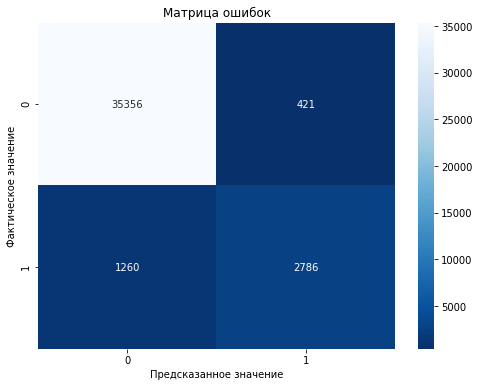

In [18]:
plt.figure(figsize = (8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues_r')
plt.title('Матрица ошибок')
plt.ylabel('Фактическое значение')
plt.xlabel('Предсказанное значениe')
plt.show()

## Выводы

Для векторизации текста комментариев был выбран расчёт TF-IDF.

В ходе работы было выполнено:
- Загрузка данных
- Преобразование текста (вне TfidfVectorizer): избавление от символов и цифр; лемматизация
- Вектаризация текста при помощи TfidfVectorizer с исклчением слов, встречающихся менее 10 раз, с исключением стоп-слов, с расчётом униграмм и биграмм (приведение к нижнему регистру выполняется внутри TfidfVectorizer)
- Обучение моделей 'Random Forest Classifier', 'KNeighbors Classifier', 'Logistic Regression', 'Linear SVC' с проверкой значения метрики F1 на кросс-валидационной выборке
- Получение предсказаний на тестовой выборке моделью LinearSVC, показавшей наилучший результат на валидационной выборке

Значение метрики F1 на тренировочной выборке 0.771. Значение метрики F1 на тестовой выборке 0.768.<br />
Переобучение не наблюдается, т.к. значение метрики почти одинаковое.<br />
Для улучшения качества предсказаний можно подобрать гиперпараметры модели и порог классификации.